In [56]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import random
from generate_data import generate_Ls, generate_sylvester_data
from proximal_gradient_descent import (
    get_optimizer_oracles,
    proximal_accelerated_gradient,
    project_to_lower_with_positive_diag,
    warm_start
)
from sklearn.metrics import homogeneity_score, completeness_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import matthews_corrcoef, precision_score, recall_score, f1_score
from plotting_utilities import get_metrics, patternify_Ls, one_example_prs
import scanpy as sc
import igraph as ig
import xarray as xr
import pickle
import itertools
import pandas as pd
from pybiomart import Dataset

# Prevent Type 3 fonts
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [89]:
gene_counts = pd.read_csv('data/real_data/CountDataset_forBailey.csv', index_col="Unnamed: 0")
gene_counts

,S2_7,S2_12,S13_9,S13_6,S13_19,S13_7,S13_8,S13_14,S13_22,S13_15,...,S14_12,S6_7,S12_3,S3_13,S4_12,S15_19,S8_21,S6_13,S11_17,S12_9
ANT1,0,0,0,2,0,126,33,0,13,222,...,0,2,0,6,1,16,0,4,0,0
ANT2,1,2,3,4,15,228,66,0,0,0,...,0,6,11,6,0,18,0,11,0,1
ANT3,2,0,1,6,0,220,80,0,9,0,...,0,0,1,11,0,18,0,5,0,30
ANT4,0,1,3,7,0,273,77,0,14,0,...,0,4,0,7,2,0,0,17,58,0
POS1,569,922,249,527,12017,1310,1583,7251,10699,121578,...,10238,4501,40018,3954,5741,58626,23264,5067,77404,24097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAP70,2389,3147,64,1033,3343,380,1338,1875,1677,606,...,453,4114,660,2158,1112,3765,10144,386,657,1403
ZHX2,2189,1058,2173,2246,1740,3408,1498,666,1376,1000,...,987,1273,533,758,804,1012,2509,1325,768,395
ZNF141_Iso1-3,3366,2440,1542,1655,563,2594,1979,420,3816,3007,...,232,6045,670,388,2065,729,6806,888,1152,187
ZNF141_Iso4-5,1000,1185,855,909,432,1288,947,348,1759,697,...,360,1977,372,454,1233,695,3082,537,535,252


In [90]:
patient_labels = pd.read_csv('data/real_data/Labeldataset_forBailey.csv')
patient_labels

,Plate,sam,Key,DAC_class,ABC,GCB,TypeIII,ClassMHG,p.MHG.
0,1,1,S1_1,GCB,0.015850,0.878891,0.105259,DLBCL,0.029
1,1,2,S1_2,ABC,0.763336,0.221205,0.015458,DLBCL,0.087
2,1,3,S1_3,GCB,0.076856,0.756450,0.166694,DLBCL,0.030
3,1,4,S1_4,GCB,0.002643,0.635766,0.361592,DLBCL,0.051
4,1,5,S1_5,ABC,0.682246,0.179717,0.138037,DLBCL,0.057
...,...,...,...,...,...,...,...,...,...
330,15,17,S15_17,GCB,0.025052,0.731591,0.243357,MHG,0.854
331,15,18,S15_18,ABC,0.867279,0.001085,0.131636,DLBCL,0.108
332,15,19,S15_19,ABC,0.713550,0.053766,0.232683,DLBCL,0.011
333,15,20,S15_20,GCB,0.000104,0.817349,0.182546,DLBCL,0.033


/Users/baileyandrew/mambaforge/envs/Cartesian-LGAM/lib/python3.12/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 316 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


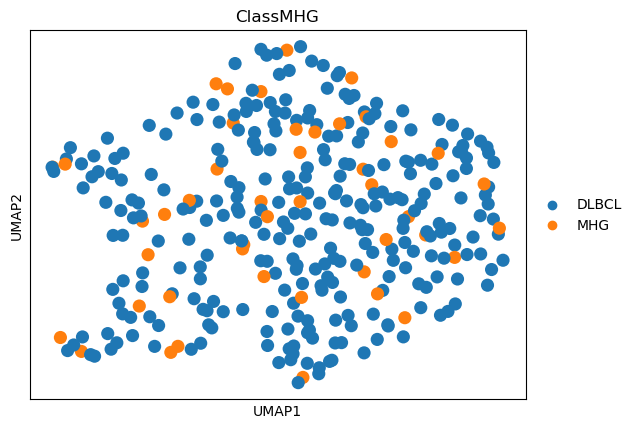

In [94]:
adata = sc.AnnData(X=gene_counts.values.T)
adata.obs['DAC_class'] = patient_labels['DAC_class'].values
adata.obs['ClassMHG'] = patient_labels['ClassMHG'].values
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color='ClassMHG')

In [99]:
adata.var_names = gene_counts.index.tolist()
sc.pp.log1p(adata)

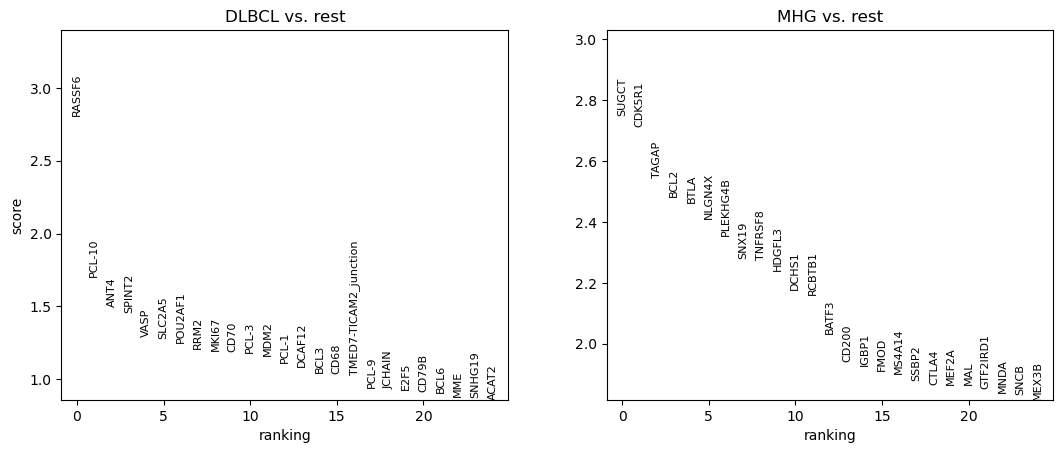

In [100]:
sc.tl.rank_genes_groups(adata, 'ClassMHG', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

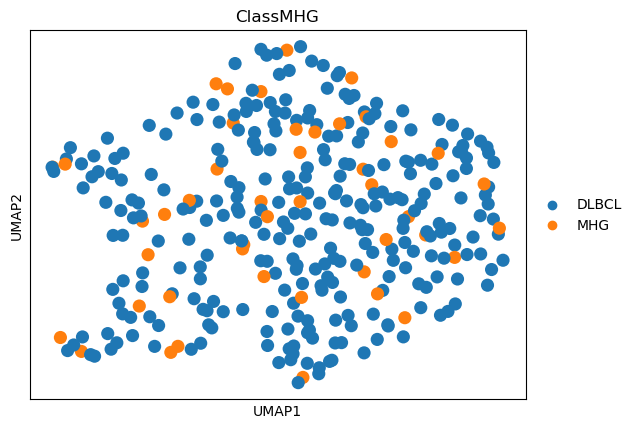

In [101]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color='ClassMHG')

In [59]:
patient_labels['ClassMHG'].value_counts()

ClassMHG
DLBCL    290
MHG       45
Name: count, dtype: int64

In [60]:
# Order genes and patients by variance:
gene_variances = gene_counts.var(axis=1)
patient_variances = gene_counts.var(axis=0)

ordered_genes = gene_variances.sort_values(ascending=True).index.tolist()
ordered_patients = patient_variances.sort_values(ascending=True).index.tolist()
#gene_counts = gene_counts.loc[ordered_genes, ordered_patients]
gene_counts

,S2_7,S2_12,S13_9,S13_6,S13_19,S13_7,S13_8,S13_14,S13_22,S13_15,...,S14_12,S6_7,S12_3,S3_13,S4_12,S15_19,S8_21,S6_13,S11_17,S12_9
ANT1,0,0,0,2,0,126,33,0,13,222,...,0,2,0,6,1,16,0,4,0,0
ANT2,1,2,3,4,15,228,66,0,0,0,...,0,6,11,6,0,18,0,11,0,1
ANT3,2,0,1,6,0,220,80,0,9,0,...,0,0,1,11,0,18,0,5,0,30
ANT4,0,1,3,7,0,273,77,0,14,0,...,0,4,0,7,2,0,0,17,58,0
POS1,569,922,249,527,12017,1310,1583,7251,10699,121578,...,10238,4501,40018,3954,5741,58626,23264,5067,77404,24097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAP70,2389,3147,64,1033,3343,380,1338,1875,1677,606,...,453,4114,660,2158,1112,3765,10144,386,657,1403
ZHX2,2189,1058,2173,2246,1740,3408,1498,666,1376,1000,...,987,1273,533,758,804,1012,2509,1325,768,395
ZNF141_Iso1-3,3366,2440,1542,1655,563,2594,1979,420,3816,3007,...,232,6045,670,388,2065,729,6806,888,1152,187
ZNF141_Iso4-5,1000,1185,855,909,432,1288,947,348,1759,697,...,360,1977,372,454,1233,695,3082,537,535,252


In [61]:
# Get which are TFs

dataset = Dataset(name='hsapiens_gene_ensembl', host='http://www.ensembl.org')

df = dataset.query(
    attributes=[
        'external_gene_name',
        'go_id',
        'name_1006',
        "ensembl_gene_id"
    ],
    filters={
        'link_go_closure': ['GO:0003700', 'GO:0140110', 'GO:0000981']
    }
)


df = df.dropna().drop_duplicates()
df

,Gene name,GO term accession,GO term name,Gene stable ID
0,HMX1,GO:0000981,"DNA-binding transcription factor activity, RNA...",ENSG00000288204
1,SHOX,GO:0000981,"DNA-binding transcription factor activity, RNA...",ENSG00000292354
2,HSFY2,GO:0003700,DNA-binding transcription factor activity,ENSG00000169953
3,HSFY2,GO:0000981,"DNA-binding transcription factor activity, RNA...",ENSG00000169953
4,HSFY1,GO:0003700,DNA-binding transcription factor activity,ENSG00000172468
...,...,...,...,...
2058,RXRG,GO:0000981,"DNA-binding transcription factor activity, RNA...",ENSG00000143171
2059,ELK4,GO:0003700,DNA-binding transcription factor activity,ENSG00000158711
2060,ELK4,GO:0000981,"DNA-binding transcription factor activity, RNA...",ENSG00000158711
2061,MEF2D,GO:0000981,"DNA-binding transcription factor activity, RNA...",ENSG00000116604


In [62]:
# Put the TFs first always!
tf_idcs = gene_counts.index.isin(df['Gene name'])
#gene_counts = pd.concat([gene_counts[tf_idcs], gene_counts[~tf_idcs]], axis=0)
gene_counts

,S2_7,S2_12,S13_9,S13_6,S13_19,S13_7,S13_8,S13_14,S13_22,S13_15,...,S14_12,S6_7,S12_3,S3_13,S4_12,S15_19,S8_21,S6_13,S11_17,S12_9
ANT1,0,0,0,2,0,126,33,0,13,222,...,0,2,0,6,1,16,0,4,0,0
ANT2,1,2,3,4,15,228,66,0,0,0,...,0,6,11,6,0,18,0,11,0,1
ANT3,2,0,1,6,0,220,80,0,9,0,...,0,0,1,11,0,18,0,5,0,30
ANT4,0,1,3,7,0,273,77,0,14,0,...,0,4,0,7,2,0,0,17,58,0
POS1,569,922,249,527,12017,1310,1583,7251,10699,121578,...,10238,4501,40018,3954,5741,58626,23264,5067,77404,24097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAP70,2389,3147,64,1033,3343,380,1338,1875,1677,606,...,453,4114,660,2158,1112,3765,10144,386,657,1403
ZHX2,2189,1058,2173,2246,1740,3408,1498,666,1376,1000,...,987,1273,533,758,804,1012,2509,1325,768,395
ZNF141_Iso1-3,3366,2440,1542,1655,563,2594,1979,420,3816,3007,...,232,6045,670,388,2065,729,6806,888,1152,187
ZNF141_Iso4-5,1000,1185,855,909,432,1288,947,348,1759,697,...,360,1977,372,454,1233,695,3082,537,535,252


In [63]:
gene_counts.values

array([[   0,    0,    0, ...,    4,    0,    0],
       [   1,    2,    3, ...,   11,    0,    1],
       [   2,    0,    1, ...,    5,    0,   30],
       ...,
       [3366, 2440, 1542, ...,  888, 1152,  187],
       [1000, 1185,  855, ...,  537,  535,  252],
       [3280, 2452, 3661, ..., 1535, 1894, 3021]])

In [64]:
# Normalize gene_counts
gene_counts = gene_counts.div(gene_counts.sum(axis=0), axis=1) * 1e4
gene_counts = np.log1p(gene_counts + 1)
gene_counts.values

array([[0.69314718, 0.69314718, 0.69314718, ..., 0.71476457, 0.69314718,
        0.69314718],
       [0.69775725, 0.70330698, 0.71397537, ..., 0.75150574, 0.69314718,
        0.70009345],
       [0.70234617, 0.69314718, 0.70013822, ..., 0.72009668, 0.69314718,
        0.88303458],
       ...,
       [3.49973394, 3.29273075, 3.16276719, ..., 2.45981249, 2.39772207,
        1.52756551],
       [2.41960577, 2.64622636, 2.63881196, ..., 2.06273539, 1.82112453,
        1.70712814],
       [3.47543495, 3.29727302, 3.97720661, ..., 2.93236526, 2.82100637,
        3.78681   ]])

In [65]:
np.log(gene_counts.values + 1)

array([[0.52658903, 0.52658903, 0.52658903, ..., 0.5392758 , 0.52658903,
        0.52658903],
       [0.52930812, 0.53257164, 0.53881545, ..., 0.56047584, 0.52658903,
        0.53068322],
       [0.5320074 , 0.52658903, 0.53070955, ..., 0.5423805 , 0.52658903,
        0.63288461],
       ...,
       [1.50401827, 1.45692307, 1.42618004, ..., 1.24121439, 1.22310523,
        0.92725659],
       [1.22952527, 1.29369276, 1.29165724, ..., 1.11930843, 1.03713557,
        0.99588834],
       [1.49860354, 1.45798064, 1.60486881, ..., 1.36924109, 1.34051384,
        1.56586422]])

In [66]:
patient_labels["DAC_class"].value_counts()

DAC_class
GCB        155
ABC        103
TypeIII     77
Name: count, dtype: int64

# Run our method

In [67]:
np.random.seed(0)
dataset = gene_counts.values.copy()

dims = dataset.shape
L_init = [np.eye(d) for d in dims]

# Generate random lower triangular matrices L_init
for L in L_init:
    np.fill_diagonal(L, 1.0)

frobreg = 0.01

patient_range = [10**3]
gene_range = [10**3]

glassoregs = [
    (y, x)
    for x in gene_range
    for y in patient_range
]

Lss, diagnostics = warm_start(
    dataset,
    L_init=L_init,
    glassoregs = glassoregs,
    frobreg=frobreg,
    mu=0.2,
    init_alpha=1,
    tau=0.5,
    beta=0.0001,
    max_iter=100,
    tol=1e-5,
    verbose=True,
    dont_warm_start=True # numerical stability is causing problems...
)

L1 Param: (1000, 1000)


/Users/baileyandrew/Cartesian-LGAM/proximal_gradient_descent.py:43: UserWarning: Alpha too small, stopping line search
  warnings.warn("Alpha too small, stopping line search")


In [68]:
gene_network = Lss[0][0].copy()
cell_network = Lss[0][1].copy()

flatgenes = gene_network[np.tril_indices_from(gene_network, k=-1)]
print((flatgenes != 0).sum() / len(flatgenes))
flatcells = cell_network[np.tril_indices_from(cell_network, k=-1)]
print((flatcells != 0).sum() / len(flatcells))

1.0
1.0


In [69]:
gene_network = Lss[0][0].copy()
cell_network = Lss[0][1].copy()

# Keep only top p% of edges, which since lower triangular requires top p/2%
p=20
gene_network[np.abs(gene_network) < np.percentile(np.abs(gene_network), 100-p/2)] = 0
cell_network[np.abs(cell_network) < np.percentile(np.abs(cell_network), 100-p/2)] = 0

In [70]:
flatgenes = gene_network[np.tril_indices_from(gene_network, k=-1)]
print((flatgenes != 0).sum() / len(flatgenes))
flatcells = cell_network[np.tril_indices_from(cell_network, k=-1)]
print((flatcells != 0).sum() / len(flatcells))

0.19429375125577658
0.194619715792296


(array([ 3663.,  7225.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 45057.]),
 array([-0.00806424, -0.00725781, -0.00645139, -0.00564496, -0.00483854,
        -0.00403212, -0.00322569, -0.00241927, -0.00161285, -0.00080642,
         0.        ]),
 <BarContainer object of 10 artists>)

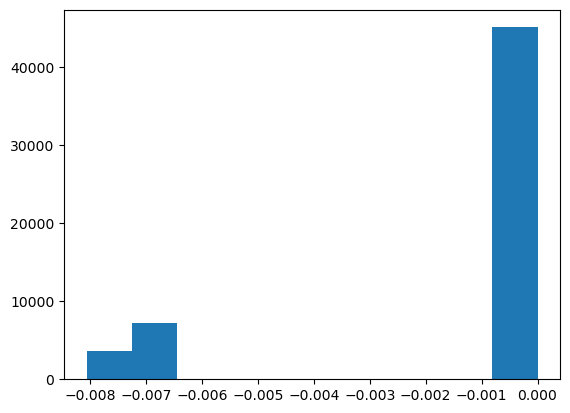

In [71]:
plt.hist(flatcells)

In [72]:
dataset.shape

(316, 335)

In [73]:
adata = sc.AnnData(X=dataset.T)
adata.obs['DAC_class'] = patient_labels['DAC_class'].values
adata.obs['ClassMHG'] = patient_labels['ClassMHG'].values
adata.obsp['cell_network'] = np.abs(cell_network)
adata.varp['gene_network'] = np.abs(gene_network)
adata.var_names = gene_counts.index
adata.obs_names = gene_counts.columns
adata

AnnData object with n_obs × n_vars = 335 × 316
    obs: 'DAC_class', 'ClassMHG'
    obsp: 'cell_network'
    varp: 'gene_network'

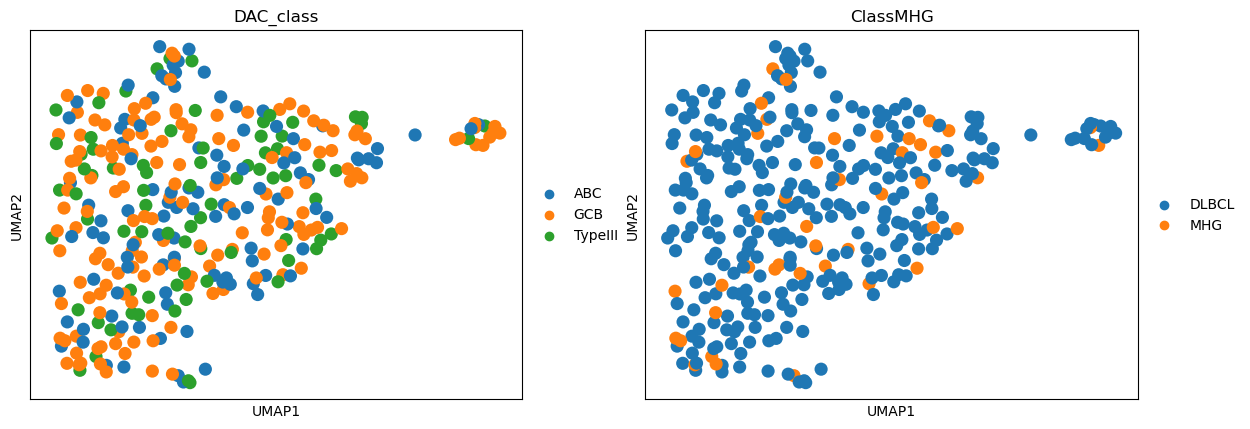

In [74]:
sc.pp.neighbors(adata, use_rep='X', n_neighbors=10)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['DAC_class', 'ClassMHG'])

In [75]:
adata.uns['clgam_neighbors_cells'] = adata.uns['neighbors'].copy()
adata.uns['clgam_neighbors_cells']['connectivities_key'] = 'cell_network'
adata.uns['clgam_neighbors_cells']['distances_key'] = 'cell_network'
adata.uns['clgam_neighbors_genes'] = adata.uns['neighbors'].copy()
adata.uns['clgam_neighbors_genes']['connectivities_key'] = 'gene_network'
adata.uns['clgam_neighbors_genes']['distances_key'] = 'gene_network'

In [76]:
if 'leiden_colors' in adata.uns:
    del adata.uns['leiden_colors']
sc.tl.leiden(adata, resolution=1, neighbors_key='clgam_neighbors_cells')

In [77]:
adata.obs['leiden'].value_counts()

leiden
0      2
229    1
227    1
226    1
225    1
      ..
110    1
109    1
108    1
107    1
333    1
Name: count, Length: 334, dtype: int64

In [78]:
adata.obs['leiden2'] = adata.obs['leiden'].copy().astype(str)
for cluster in adata.obs['leiden'].unique():
    idcs = adata.obs['leiden'] == cluster
    if idcs.sum() < 5:
        adata.obs.loc[idcs, 'leiden2'] = 'singleton'
adata.obs['leiden2'].value_counts()

leiden2
singleton    335
Name: count, dtype: int64

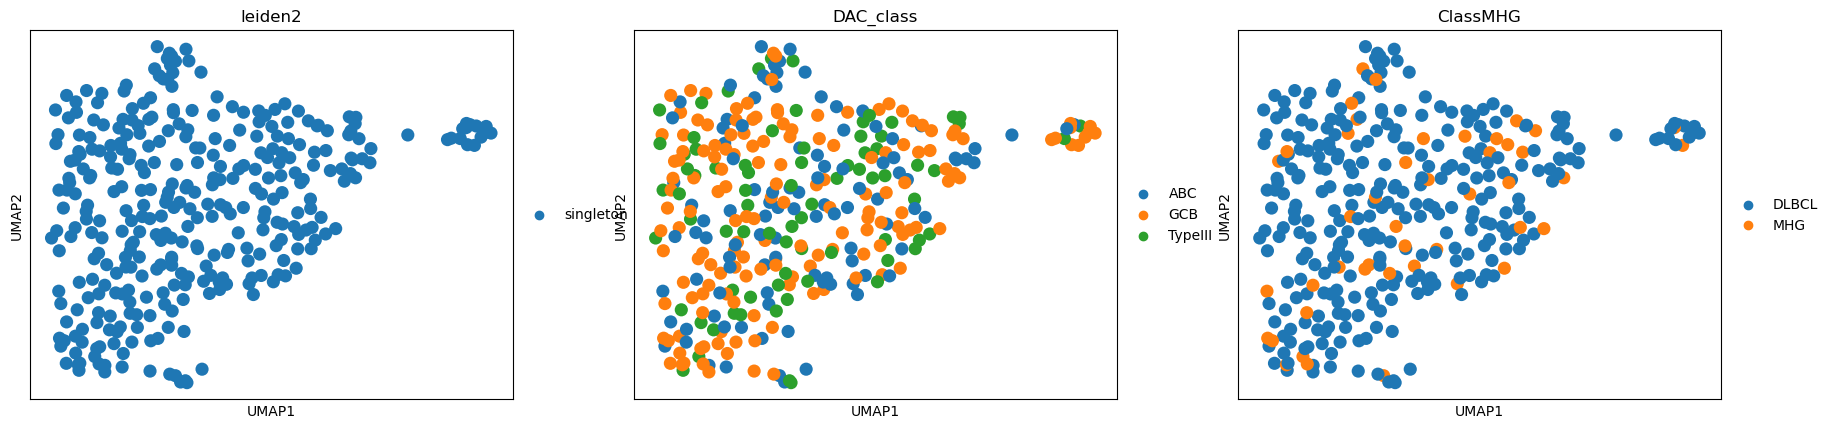

In [79]:
if 'leiden2_colors' in adata.uns:
    del adata.uns['leiden2_colors']
sc.pl.umap(adata, color=['leiden2', 'DAC_class', 'ClassMHG'])

In [80]:
display(pd.crosstab(adata.obs['leiden2'], adata.obs['DAC_class'], normalize='index'))
display(pd.crosstab(adata.obs['leiden2'], adata.obs['DAC_class'], normalize='columns'))

DAC_class,ABC,GCB,TypeIII
leiden2,,,
singleton,0.307463,0.462687,0.229851


DAC_class,ABC,GCB,TypeIII
leiden2,,,
singleton,1.0,1.0,1.0


In [81]:
display(pd.crosstab(adata.obs['leiden2'], adata.obs['ClassMHG'], normalize='index'))
display(pd.crosstab(adata.obs['leiden2'], adata.obs['ClassMHG'], normalize='columns'))

ClassMHG,DLBCL,MHG
leiden2,,
singleton,0.865672,0.134328


ClassMHG,DLBCL,MHG
leiden2,,
singleton,1.0,1.0


In [82]:
bdata = adata.transpose()
sc.tl.leiden(bdata, resolution=0.9, neighbors_key='clgam_neighbors_genes')
bdata.obs['leiden'].value_counts()

leiden
0      13
1      11
2       3
10      2
17      2
       ..
107     1
108     1
109     1
110     1
276     1
Name: count, Length: 277, dtype: int64

In [83]:
for name in bdata.obs_names[bdata.obs['leiden'] == '0']:
    print(name)

POS1
POS2
POS3
POS4
AKT1
ALOX5
ANXA1
ARHGAP25
BANK1
BATF
BCL10
BCL2
BCL2A1


In [84]:
for name in bdata.obs_names[bdata.obs['leiden'] == '1']:
    print(name)

STAT3
TAGAP
TCF4
TMED7-TICAM2_5p
TUBA1A
TYMS
UBE4A
VASP
VDAC1
VOPP1
XIAP


In [85]:
for name in bdata.obs_names[bdata.obs['leiden'] == '2']:
    print(name)

SNX19
SPI1
SREBF1


[igraph.Edge(<igraph.Graph object at 0x161eccc50>, 0, {}), igraph.Edge(<igraph.Graph object at 0x161eccc50>, 1, {}), igraph.Edge(<igraph.Graph object at 0x161eccc50>, 2, {}), igraph.Edge(<igraph.Graph object at 0x161eccc50>, 3, {}), igraph.Edge(<igraph.Graph object at 0x161eccc50>, 4, {}), igraph.Edge(<igraph.Graph object at 0x161eccc50>, 5, {}), igraph.Edge(<igraph.Graph object at 0x161eccc50>, 6, {}), igraph.Edge(<igraph.Graph object at 0x161eccc50>, 7, {}), igraph.Edge(<igraph.Graph object at 0x161eccc50>, 8, {}), igraph.Edge(<igraph.Graph object at 0x161eccc50>, 9, {}), igraph.Edge(<igraph.Graph object at 0x161eccc50>, 10, {}), igraph.Edge(<igraph.Graph object at 0x161eccc50>, 11, {}), igraph.Edge(<igraph.Graph object at 0x161eccc50>, 12, {}), igraph.Edge(<igraph.Graph object at 0x161eccc50>, 13, {}), igraph.Edge(<igraph.Graph object at 0x161eccc50>, 14, {}), igraph.Edge(<igraph.Graph object at 0x161eccc50>, 15, {}), igraph.Edge(<igraph.Graph object at 0x161eccc50>, 16, {}), igraph

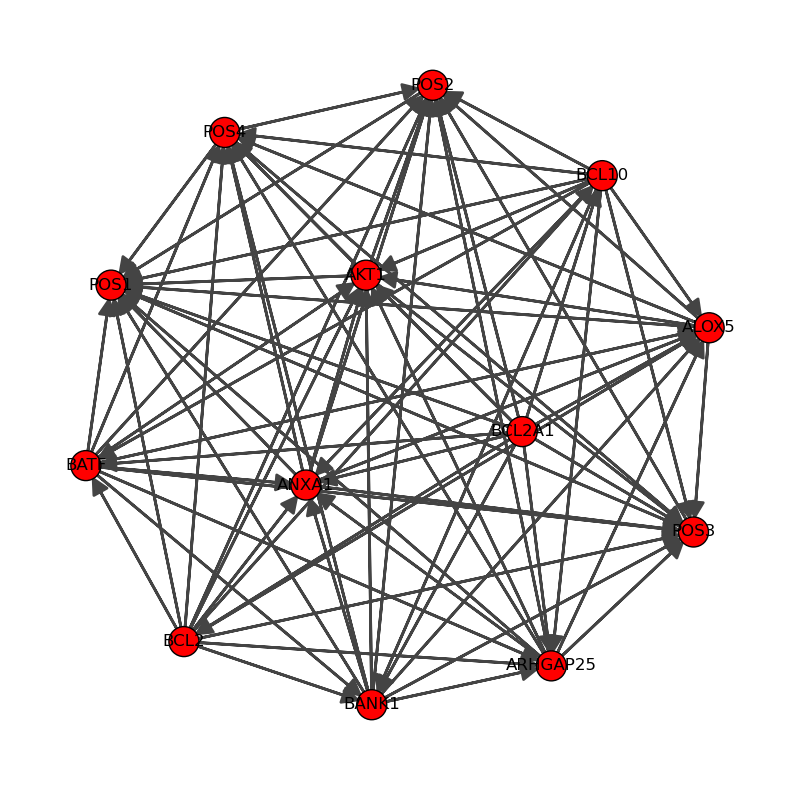

In [86]:
bdata_0 = bdata[bdata.obs['leiden'] == '0']

# Convert graph to igraph and display it
fig, ax = plt.subplots(figsize=(10,10))
graph = ig.Graph.Adjacency(bdata_0.obsp['gene_network'] != 0, mode="directed").simplify()
graph.vs['name'] = bdata_0.obs_names.tolist()
print(list(graph.es))

ig.plot(graph, layout='fr', target=ax, vertex_label=graph.vs['name'])

[igraph.Edge(<igraph.Graph object at 0x161b69650>, 0, {}), igraph.Edge(<igraph.Graph object at 0x161b69650>, 1, {}), igraph.Edge(<igraph.Graph object at 0x161b69650>, 2, {}), igraph.Edge(<igraph.Graph object at 0x161b69650>, 3, {}), igraph.Edge(<igraph.Graph object at 0x161b69650>, 4, {}), igraph.Edge(<igraph.Graph object at 0x161b69650>, 5, {}), igraph.Edge(<igraph.Graph object at 0x161b69650>, 6, {}), igraph.Edge(<igraph.Graph object at 0x161b69650>, 7, {}), igraph.Edge(<igraph.Graph object at 0x161b69650>, 8, {}), igraph.Edge(<igraph.Graph object at 0x161b69650>, 9, {}), igraph.Edge(<igraph.Graph object at 0x161b69650>, 10, {}), igraph.Edge(<igraph.Graph object at 0x161b69650>, 11, {}), igraph.Edge(<igraph.Graph object at 0x161b69650>, 12, {}), igraph.Edge(<igraph.Graph object at 0x161b69650>, 13, {}), igraph.Edge(<igraph.Graph object at 0x161b69650>, 14, {}), igraph.Edge(<igraph.Graph object at 0x161b69650>, 15, {}), igraph.Edge(<igraph.Graph object at 0x161b69650>, 16, {}), igraph

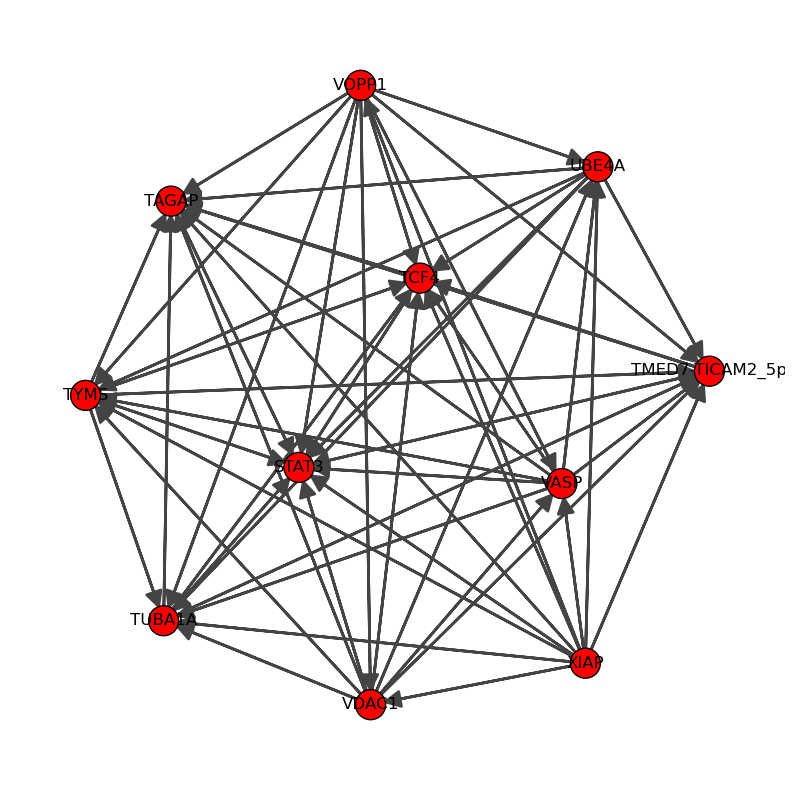

In [87]:
bdata_1 = bdata[bdata.obs['leiden'] == '1']

# Convert graph to igraph and display it
fig, ax = plt.subplots(figsize=(10,10))
graph = ig.Graph.Adjacency(bdata_1.obsp['gene_network'] != 0, mode="directed").simplify()
graph.vs['name'] = bdata_1.obs_names.tolist()
print(list(graph.es))

ig.plot(graph, layout='fr', target=ax, vertex_label=graph.vs['name'])

[igraph.Edge(<igraph.Graph object at 0x164317050>, 0, {}), igraph.Edge(<igraph.Graph object at 0x164317050>, 1, {}), igraph.Edge(<igraph.Graph object at 0x164317050>, 2, {}), igraph.Edge(<igraph.Graph object at 0x164317050>, 3, {}), igraph.Edge(<igraph.Graph object at 0x164317050>, 4, {}), igraph.Edge(<igraph.Graph object at 0x164317050>, 5, {}), igraph.Edge(<igraph.Graph object at 0x164317050>, 6, {}), igraph.Edge(<igraph.Graph object at 0x164317050>, 7, {}), igraph.Edge(<igraph.Graph object at 0x164317050>, 8, {}), igraph.Edge(<igraph.Graph object at 0x164317050>, 9, {}), igraph.Edge(<igraph.Graph object at 0x164317050>, 10, {}), igraph.Edge(<igraph.Graph object at 0x164317050>, 11, {}), igraph.Edge(<igraph.Graph object at 0x164317050>, 12, {}), igraph.Edge(<igraph.Graph object at 0x164317050>, 13, {}), igraph.Edge(<igraph.Graph object at 0x164317050>, 14, {}), igraph.Edge(<igraph.Graph object at 0x164317050>, 15, {}), igraph.Edge(<igraph.Graph object at 0x164317050>, 16, {}), igraph

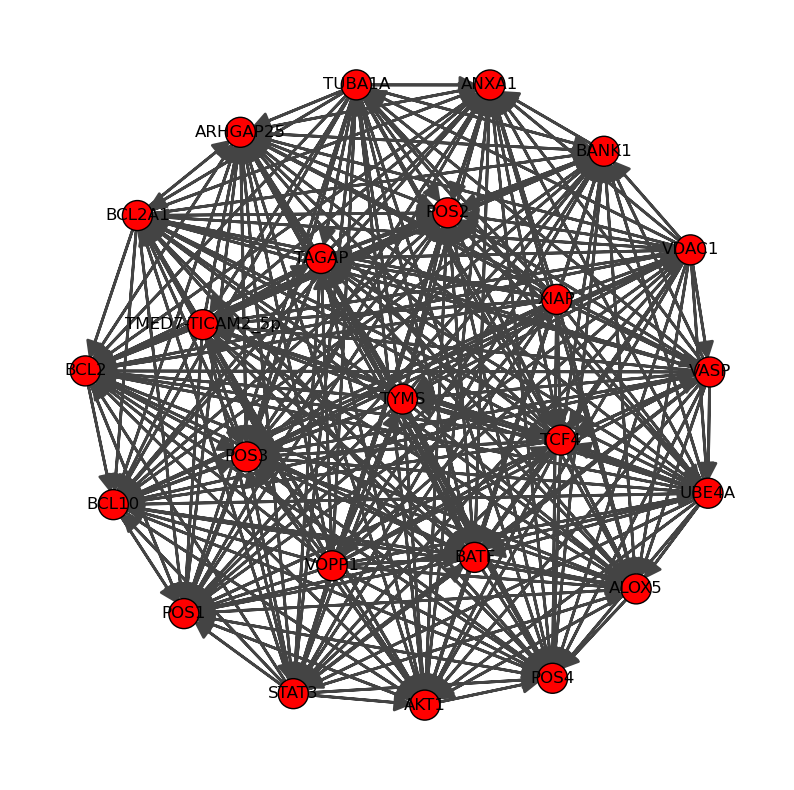

In [88]:
bdata_01 = bdata[bdata.obs['leiden'].isin(['1', '0'])]

# Convert graph to igraph and display it
fig, ax = plt.subplots(figsize=(10,10))
graph = ig.Graph.Adjacency(bdata_01.obsp['gene_network'] != 0, mode="directed").simplify()
graph.vs['name'] = bdata_01.obs_names.tolist()
print(list(graph.es))

ig.plot(graph, layout='fr', target=ax, vertex_label=graph.vs['name'])